# Análise de Dataset de GPUs 📊

📦 **Carregamento & Importação:** Prepara o ambiente e carrega o dataset de GPUs.

In [5]:
import pandas as pd
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_aa5044be6fd203b1942bc7fbd9929067"

print("📥 Baixando e extraindo o dataset de especificações de placas de vídeo...")

# 1.baixar dataset
!kaggle datasets download -d alanjo/graphics-card-full-specs

# 2. Extrair arquivo
!unzip -o graphics-card-full-specs.zip # Use -o para sobrescrever arquivos existentes sem prompt

# Carrega o dataset para análise
df = pd.read_csv('gpu_specs_v7.csv')

print("✅ Dataset de Placas de Vídeo carregado com sucesso!")

print("\n📊 Informações básicas do dataset:")
print(f"📏 Dimensões: {df.shape}")
print(f"📋 Colunas: {list(df.columns)}")

print("\n🔍 Primeiras 5 linhas:")
display(df.head())

📥 Baixando e extraindo o dataset de especificações de placas de vídeo...
Dataset URL: https://www.kaggle.com/datasets/alanjo/graphics-card-full-specs
License(s): CC0-1.0
graphics-card-full-specs.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  graphics-card-full-specs.zip
  inflating: gpu_specs_v6.csv        
  inflating: gpu_specs_v7.csv        
✅ Dataset de Placas de Vídeo carregado com sucesso!

📊 Informações básicas do dataset:
📏 Dimensões: (3056, 16)
📋 Colunas: ['manufacturer', 'productName', 'releaseYear', 'memSize', 'memBusWidth', 'gpuClock', 'memClock', 'unifiedShader', 'tmu', 'rop', 'pixelShader', 'vertexShader', 'igp', 'bus', 'memType', 'gpuChip']

🔍 Primeiras 5 linhas:


,manufacturer,productName,releaseYear,memSize,memBusWidth,gpuClock,memClock,unifiedShader,tmu,rop,pixelShader,vertexShader,igp,bus,memType,gpuChip
0,NVIDIA,GeForce RTX 5090,2025.0,28.0,448.0,900,1200.0,8192.0,256,128,NaN,NaN,No,PCIe 4.0 x16,HBM2e,Arctic Sound
1,NVIDIA,GeForce RTX 5080,2025.0,16.0,256.0,900,1215.0,6912.0,432,192,NaN,NaN,No,PCIe 4.0 x16,HBM2e,GA100
2,NVIDIA,GeForce RTX 5070,2025.0,12.0,192.0,1825,2000.0,5120.0,320,128,NaN,NaN,No,PCIe 4.0 x16,GDDR6,Navi 21
3,NVIDIA,GeForce RTX 5060 Mobile,2025.0,8.0,128.0,2235,2500.0,4608.0,144,48,NaN,NaN,No,PCIe 5.0 x16,GDDR7,GB206
4,NVIDIA,GeForce RTX 5060,2025.0,8.0,128.0,1825,2250.0,4608.0,288,192,NaN,NaN,No,PCIe 4.0 x16,GDDR6,Navi 31


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

## 🧹 Limpeza dos Dados

Nesta etapa, realizaremos a limpeza dos dados, que inclui a verificação de valores ausentes, tipos de dados e a remoção de duplicatas para garantir a qualidade e consistência do dataset.

🔍 **Verificação de Dados:** Exibe informações gerais do DataFrame, valores ausentes e linhas duplicadas para entender a integridade dos dados.

In [7]:
# Visualiza informações gerais sobre o DataFrame, incluindo tipos de dados e valores não nulos
display(df.info())

# Verifica a quantidade de valores ausentes por coluna
print('\nValores ausentes por coluna:')
display(df.isnull().sum())

# Verifica a quantidade de linhas duplicadas
print('\nLinhas duplicadas:')
display(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3056 entries, 0 to 3055
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   manufacturer   3056 non-null   object 
 1   productName    3056 non-null   object 
 2   releaseYear    3012 non-null   float64
 3   memSize        2615 non-null   float64
 4   memBusWidth    188 non-null    float64
 5   gpuClock       3056 non-null   int64  
 6   memClock       2615 non-null   float64
 7   unifiedShader  2232 non-null   float64
 8   tmu            3056 non-null   int64  
 9   rop            3056 non-null   int64  
 10  pixelShader    824 non-null    float64
 11  vertexShader   824 non-null    float64
 12  igp            3056 non-null   object 
 13  bus            3056 non-null   object 
 14  memType        2615 non-null   object 
 15  gpuChip        3056 non-null   object 
dtypes: float64(7), int64(3), object(6)
memory usage: 382.1+ KB


None


Valores ausentes por coluna:


,0
manufacturer,0
productName,0
releaseYear,44
memSize,441
memBusWidth,2868
gpuClock,0
memClock,441
unifiedShader,824
tmu,0
rop,0



Linhas duplicadas:


np.int64(20)

🧹 **Tratamento de Ausentes:** Preenche valores ausentes em colunas chave (`releaseYear`, `memSize`, `memClock`, `memType`, `unifiedShader`) e remove colunas com alta porcentagem de dados faltantes.

In [9]:
# Identificando colunas com grande quantidade de valores ausentes para possível remoção ou tratamento específico
missing_values_count = df.isnull().sum()
large_missing_columns = missing_values_count[missing_values_count > (len(df) * 0.50)].index.tolist()

print(f"\nColunas com mais de 50% de valores ausentes: {large_missing_columns}")

# Vamos analisar a coluna 'releaseYear' e 'memSize' que possuem valores ausentes mas são importantes
# Para 'releaseYear', vamos preencher com a moda (ano mais comum) ou um valor sentinela, após converter para int
# Para 'memSize' e 'memClock', vamos preencher com a mediana para não introduzir outliers

# Preenchendo 'releaseYear' com a moda e convertendo para inteiro
if 'releaseYear' in df.columns:
    mode_release_year = df['releaseYear'].mode()[0]
    df['releaseYear'] = df['releaseYear'].fillna(mode_release_year).astype(int)
    print(f"\n'releaseYear' preenchido com a moda ({mode_release_year}) e convertido para int.")

# Preenchendo 'memSize' e 'memClock' com a mediana
for col in ['memSize', 'memClock', 'unifiedShader']:
    if col in df.columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)
        print(f"'{col}' preenchido com a mediana ({median_value}).")

if 'memType' in df.columns:
    mode_mem_type = df['memType'].mode()[0]
    df['memType'] = df['memType'].fillna(mode_mem_type)
    print(f"'memType' preenchido com a moda ({mode_mem_type}).")


df_cleaned = df.drop(columns=large_missing_columns, errors='ignore')

print("\nApós a limpeza e tratamento de valores ausentes:")
display(df_cleaned.info())
display(df_cleaned.isnull().sum())


Colunas com mais de 50% de valores ausentes: ['memBusWidth', 'pixelShader', 'vertexShader']

'releaseYear' preenchido com a moda (2013) e convertido para int.
'memSize' preenchido com a mediana (1.024).
'memClock' preenchido com a mediana (900.0).
'unifiedShader' preenchido com a mediana (448.0).
'memType' preenchido com a moda (GDDR5).

Após a limpeza e tratamento de valores ausentes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3056 entries, 0 to 3055
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   manufacturer   3056 non-null   object 
 1   productName    3056 non-null   object 
 2   releaseYear    3056 non-null   int64  
 3   memSize        3056 non-null   float64
 4   gpuClock       3056 non-null   int64  
 5   memClock       3056 non-null   float64
 6   unifiedShader  3056 non-null   float64
 7   tmu            3056 non-null   int64  
 8   rop            3056 non-null   int64  
 9   igp           

None

,0
manufacturer,0
productName,0
releaseYear,0
memSize,0
gpuClock,0
memClock,0
unifiedShader,0
tmu,0
rop,0
igp,0


## 📊 Análise Exploratória e Visualizações Informativas

Agora que os dados estão mais limpos, podemos prosseguir com a análise exploratória para entender a distribuição das variáveis, identificar padrões e relações, e gerar visualizações informativas.

🧐 **Estrutura e Qualidade:** Visualiza o formato do `df_cleaned`, tipos de dados, contagem de nulos e duplicatas. 📊 **Estatísticas Descritivas:** Exibe medidas de tendência central, dispersão e quartis.

In [ ]:
# 1. Compreensão da Estrutura
print('📏 Dimensões do dataset (linhas, colunas):', df_cleaned.shape)
print('\n📋 Informações sobre os tipos de dados e valores não-nulos:')
display(df_cleaned.info())

# 2. Diagnóstico de Qualidade
print('\n🔍 Valores ausentes após a limpeza:')
display(df_cleaned.isnull().sum())
print('\n🔎 Linhas duplicadas após a limpeza:')
display(df_cleaned.duplicated().sum())

# 3. Estatística Descritiva
print('\n📊 Estatísticas Descritivas para colunas numéricas e categóricas:')
display(df_cleaned.describe(include='all'))

📈 **Clocks da GPU e Memória:** Gráfico de linhas que compara a variação dos clocks de GPU e memória para as primeiras 100 placas de vídeo.

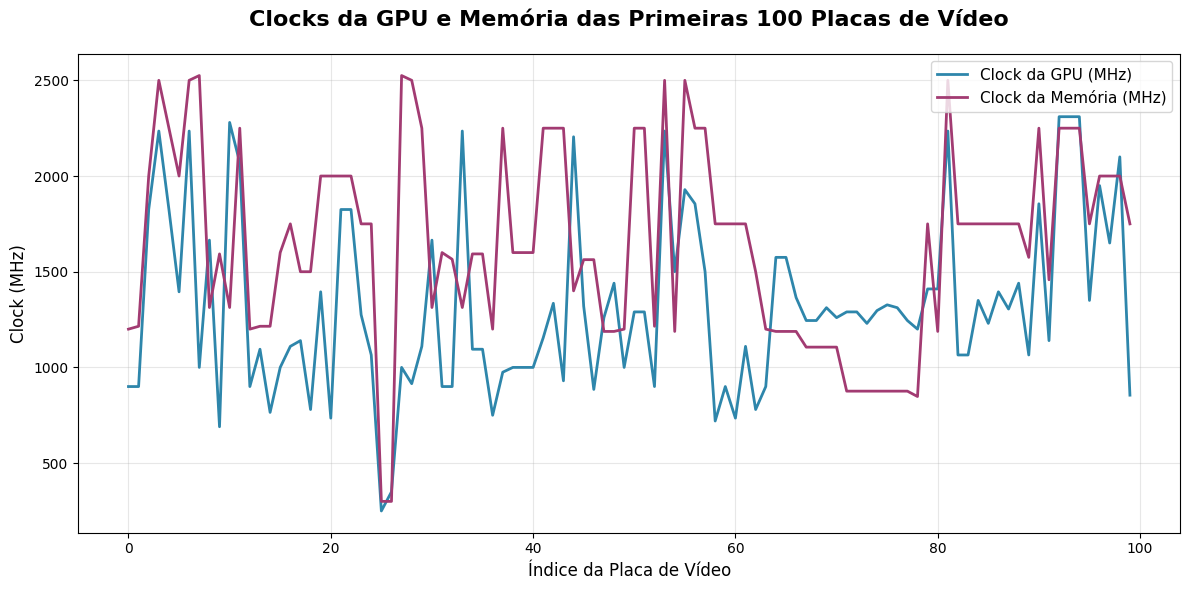

📊 Análise do Gráfico de Linhas (Clocks):
✓ Clock médio da GPU: 694.62 MHz
✓ Clock médio da Memória: 919.12 MHz
✓ Observamos a variação dos clocks para as primeiras GPUs. Pode haver uma correlação ou diferença entre eles.


In [10]:
# Gráfico de Linhas - Clocks da GPU e Memória
# Pegar as primeiras 100 GPUs para uma visualização mais clara da tendência
plt.figure(figsize=(12, 6))

# Plotando as duas séries de dados
if 'gpuClock' in df.columns and 'memClock' in df.columns:
    plt.plot(df['gpuClock'].head(100), label='Clock da GPU (MHz)', color='#2E86AB', linewidth=2)
    plt.plot(df['memClock'].head(100), label='Clock da Memória (MHz)', color='#A23B72', linewidth=2)

# Personalização do gráfico
plt.title('Clocks da GPU e Memória das Primeiras 100 Placas de Vídeo', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Índice da Placa de Vídeo', fontsize=12)
plt.ylabel('Clock (MHz)', fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análise rápida
print("📊 Análise do Gráfico de Linhas (Clocks):")
if 'gpuClock' in df.columns and 'memClock' in df.columns:
    print(f"✓ Clock médio da GPU: {df['gpuClock'].mean():.2f} MHz")
    print(f"✓ Clock médio da Memória: {df['memClock'].mean():.2f} MHz")
    print("✓ Observamos a variação dos clocks para as primeiras GPUs. Pode haver uma correlação ou diferença entre eles.")
else:
    print("Colunas 'gpuClock' ou 'memClock' não encontradas ou não são numéricas.")

📊 **Distribuição da VRAM:** Histograma que mostra a frequência dos diferentes tamanhos de memória (VRAM) das GPUs, com a média destacada.

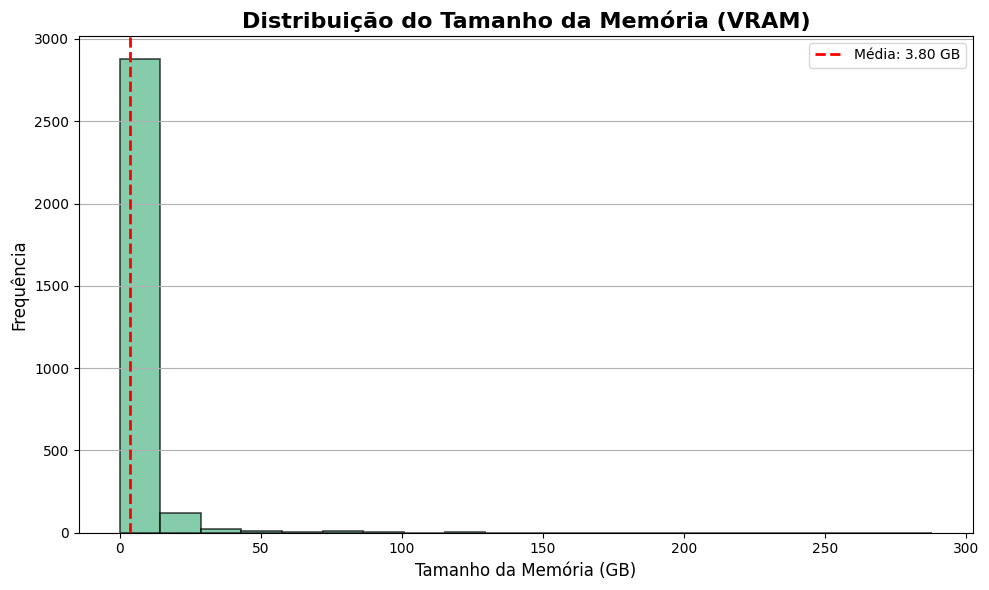

📊 Análise do Histograma (Tamanho da Memória):
✓ Média: 3.80 GB
✓ Mediana: 1.02 GB
✓ Desvio padrão: 11.32 GB
✓ Mínimo: 0.00 GB
✓ Máximo: 288.00 GB

🔍 Observações:
✓ O histograma mostra as concentrações mais comuns de VRAM nas placas de vídeo.
✓ Podemos identificar as faixas de memória mais populares ou a existência de categorias distintas (e.g., baixo, médio, alto).


In [11]:
# Histograma - Distribuição do Tamanho da Memória (VRAM)
plt.figure(figsize=(10, 6))

# Certifique-se de que a coluna existe e é numérica
if 'memSize' in df.columns:
    # Removendo valores NaN para o histograma
    mem_size_data = df['memSize'].dropna()
    if not mem_size_data.empty:
        plt.hist(mem_size_data, bins=20, color='#52B788', alpha=0.7, edgecolor='black', linewidth=1.2)
        # Personalizando o gráfico
        plt.title('Distribuição do Tamanho da Memória (VRAM)', fontsize=16, fontweight='bold')
        plt.xlabel('Tamanho da Memória (GB)', fontsize=12)
        plt.ylabel('Frequência', fontsize=12)
        plt.grid(True, alpha=1, axis='y')

        # Adicionando linha da média
        media_mem_size = mem_size_data.mean()
        plt.axvline(x=media_mem_size, color='red', linestyle='--', linewidth=2, label=f'Média: {media_mem_size:.2f} GB')
        plt.legend()

        plt.tight_layout()
        plt.show()

        # Análise estatística detalhada
        print("📊 Análise do Histograma (Tamanho da Memória):")
        print(f"✓ Média: {mem_size_data.mean():.2f} GB")
        print(f"✓ Mediana: {mem_size_data.median():.2f} GB")
        print(f"✓ Desvio padrão: {mem_size_data.std():.2f} GB")
        print(f"✓ Mínimo: {mem_size_data.min():.2f} GB")
        print(f"✓ Máximo: {mem_size_data.max():.2f} GB")
        print("\n🔍 Observações:")
        print("✓ O histograma mostra as concentrações mais comuns de VRAM nas placas de vídeo.")
        print("✓ Podemos identificar as faixas de memória mais populares ou a existência de categorias distintas (e.g., baixo, médio, alto).")
    else:
        print("A coluna 'memSize' está vazia ou contém apenas valores NaN.")
else:
    print("Coluna 'memSize' não encontrada ou não é numérica.")

📉 **Clock por Fabricante:** Gráfico de barras exibindo a média do clock da GPU por fabricante, identificando quem produz GPUs com clocks mais altos.

/tmp/ipykernel_2939/1672319540.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='manufacturer', y='gpuClock', data=df_filtered,
/tmp/ipykernel_2939/1672319540.py:28: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


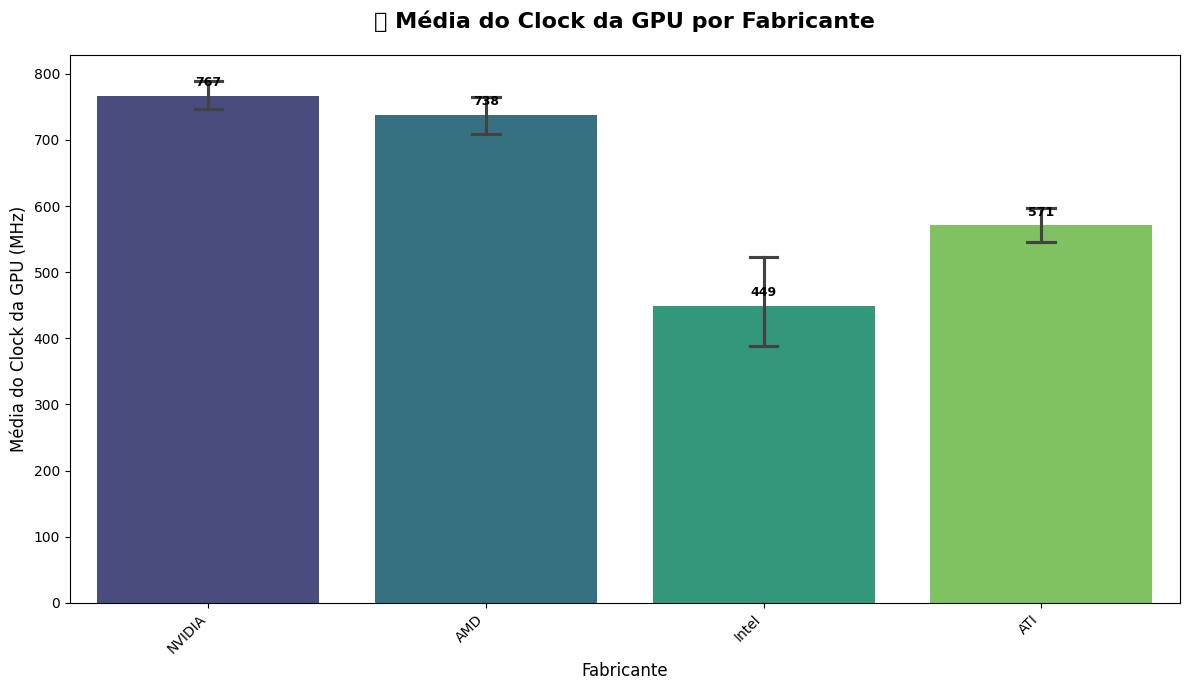

📊 Análise Estatística por Fabricante (Clock da GPU):
                mean     std  min   max
manufacturer                           
AMD           737.76  413.74  143  2321
ATI           571.14  319.17   10  2039
Intel         448.78  491.61   10  2321
NVIDIA        767.25  414.28   10  2340

🔍 Observações:
✓ Este gráfico compara a média do clock da GPU entre os principais fabricantes.
✓ Podemos ver qual fabricante tende a produzir GPUs com clocks mais altos ou mais baixos em média.


In [12]:
# Gráfico de Barras - Média do Clock da GPU por Fabricante
plt.figure(figsize=(12, 7))

# Certifique-se de que as colunas existem e são numéricas/categóricas
if 'manufacturer' in df.columns and 'gpuClock' in df.columns:
    # Limpar fabricantes com poucos dados para evitar gráficos muito poluídos
    manufacturer_counts = df['manufacturer'].value_counts()
    top_manufacturers = manufacturer_counts[manufacturer_counts > 50].index # Exemplo: apenas fabricantes com mais de 50 GPUs
    df_filtered = df[df['manufacturer'].isin(top_manufacturers)]

    if not df_filtered.empty:
        ax = sns.barplot(x='manufacturer', y='gpuClock', data=df_filtered,
                        palette='viridis', errorbar=('ci', 95), capsize=0.1)

        # Personalizando o gráfico
        plt.title('📊 Média do Clock da GPU por Fabricante', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Fabricante', fontsize=12)
        plt.ylabel('Média do Clock da GPU (MHz)', fontsize=12)
        plt.xticks(rotation=45, ha='right')

        # Adicionando valores nas barras
        for i, bar in enumerate(ax.patches):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 10, # Ajuste para posicionamento acima da barra
                    f'{bar.get_height():.0f}',
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

        plt.tight_layout()
        plt.show()

        # Análise estatística por fabricante
        print("📊 Análise Estatística por Fabricante (Clock da GPU):")
        print("=" * 60)
        fabricantes_stats = df_filtered.groupby('manufacturer')['gpuClock'].agg(['mean', 'std', 'min', 'max'])
        print(fabricantes_stats.round(2))

        print("\n🔍 Observações:")
        print("✓ Este gráfico compara a média do clock da GPU entre os principais fabricantes.")
        print("✓ Podemos ver qual fabricante tende a produzir GPUs com clocks mais altos ou mais baixos em média.")
    else:
        print("Dados insuficientes após filtrar fabricantes com poucos registros.")
else:
    print("Colunas 'manufacturer' ou 'gpuClock' não encontradas ou não são adequadas.")

📦 **VRAM por Fabricante:** Boxplot da distribuição do tamanho da memória (VRAM) entre os fabricantes, revelando a consistência e variabilidade da oferta.

/tmp/ipykernel_2939/961204531.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='manufacturer', y='memSize', data=df_filtered,
/tmp/ipykernel_2939/961204531.py:25: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


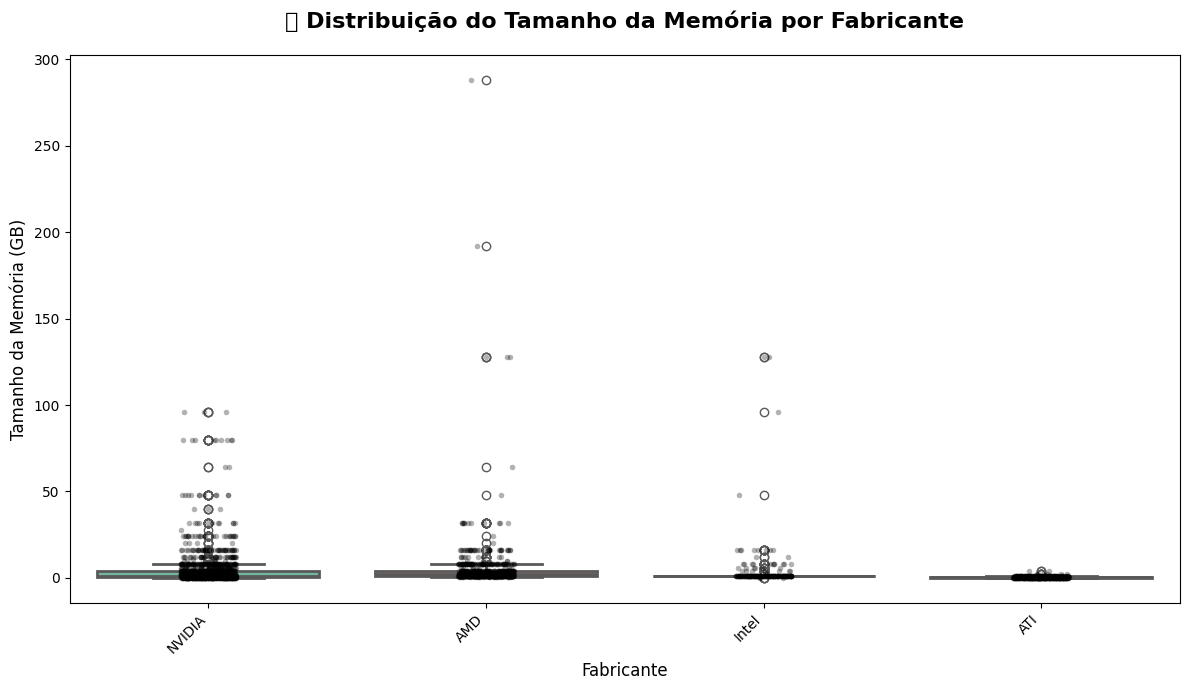

📊 Análise Detalhada dos Quartis (Tamanho da Memória por Fabricante):


In [14]:
# Boxplot - Distribuição do Tamanho da Memória por Fabricante
plt.figure(figsize=(12, 7))

# Certifique-se de que as colunas existem e são numéricas/categóricas
if 'manufacturer' in df.columns and 'memSize' in df.columns:
    # Limpar fabricantes com poucos dados para evitar gráficos muito poluídos
    manufacturer_counts = df['manufacturer'].value_counts()
    top_manufacturers = manufacturer_counts[manufacturer_counts > 50].index # Exemplo: apenas fabricantes com mais de 50 GPUs
    df_filtered = df[df['manufacturer'].isin(top_manufacturers)]

    if not df_filtered.empty:
        ax = sns.boxplot(x='manufacturer', y='memSize', data=df_filtered,
                        palette='Set2', linewidth=2)

        # Personalizando o gráfico
        plt.title('📦 Distribuição do Tamanho da Memória por Fabricante', fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Fabricante', fontsize=12)
        plt.ylabel('Tamanho da Memória (GB)', fontsize=12)
        plt.xticks(rotation=45, ha='right')

        # Adicionando pontos individuais (strip plot) para ver a dispersão real
        sns.stripplot(x='manufacturer', y='memSize', data=df_filtered,
                      color='black', alpha=0.3, size=4, ax=ax)

        plt.tight_layout()
        plt.show()

        # Análise detalhada dos quartis
        print("📊 Análise Detalhada dos Quartis (Tamanho da Memória por Fabricante):")
        print("=" * 70)

        for manufacturer in top_manufacturers:
            dados_fabricante = df_filtered[df_filtered['manufacturer'] == manufacturer]['memSize'].dropna()
            if not dados_fabricante.empty:
                q1 = dados_fabricante.quantile(0.25)
                q2 = dados_fabricante.quantile(0.50)  # Mediana
                q3 = dados_fabricante.quantile(0.75)
                iqr = q3 - q1

✍️ **Insights Extraídos:** Análise dos principais padrões e informações relevantes identificadas nas visualizações.

⚔️ **Comparativo de Fabricantes (Pós-2022):** Analisa e compara as GPUs da Intel com NVIDIA e AMD a partir de 2022, focando em métricas chave como `memSize`, `gpuClock`, `memClock` e `unifiedShader`.

In [18]:
# 1. Filtrar DataFrame para anos de lançamento a partir de 2022
df_2022_onwards = df_cleaned[df_cleaned['releaseYear'] >= 2022].copy()

# Filtrar apenas as marcas de interesse
relevant_manufacturers = ['NVIDIA', 'AMD', 'Intel']
df_filtered_brands = df_2022_onwards[df_2022_onwards['manufacturer'].isin(relevant_manufacturers)]

# Métricas para comparação
metrics = ['memSize', 'gpuClock', 'memClock', 'unifiedShader']

# 2. Calcular a média das principais especificações técnicas agrupadas por fabricante
comparative_means = df_filtered_brands.groupby('manufacturer')[metrics].mean()

# 3. Exibir tabela comparativa de médias formatada
print("📊 Tabela Comparativa de Médias (GPUs lançadas a partir de 2022):\n")
display(comparative_means.round(2))

📊 Tabela Comparativa de Médias (GPUs lançadas a partir de 2022):



,memSize,gpuClock,memClock,unifiedShader
manufacturer,,,,
AMD,18.10,1029.23,1211.40,5590.71
Intel,12.93,948.79,1028.85,5685.11
NVIDIA,20.95,1293.81,1610.54,7006.90


📈 **Visualização Comparativa:** Gera gráficos de barras para cada métrica, permitindo uma comparação visual direta entre Intel, NVIDIA e AMD.

/tmp/ipykernel_2939/1013790034.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparative_means.index, y=comparative_means[metric], ax=axes[i], palette='viridis')
/tmp/ipykernel_2939/1013790034.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparative_means.index, y=comparative_means[metric], ax=axes[i], palette='viridis')
/tmp/ipykernel_2939/1013790034.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparative_means.index, y=comparative_means[metric], ax=axes[i], palette='viridis')
/tmp/ipykernel_2939/1013790034.py:

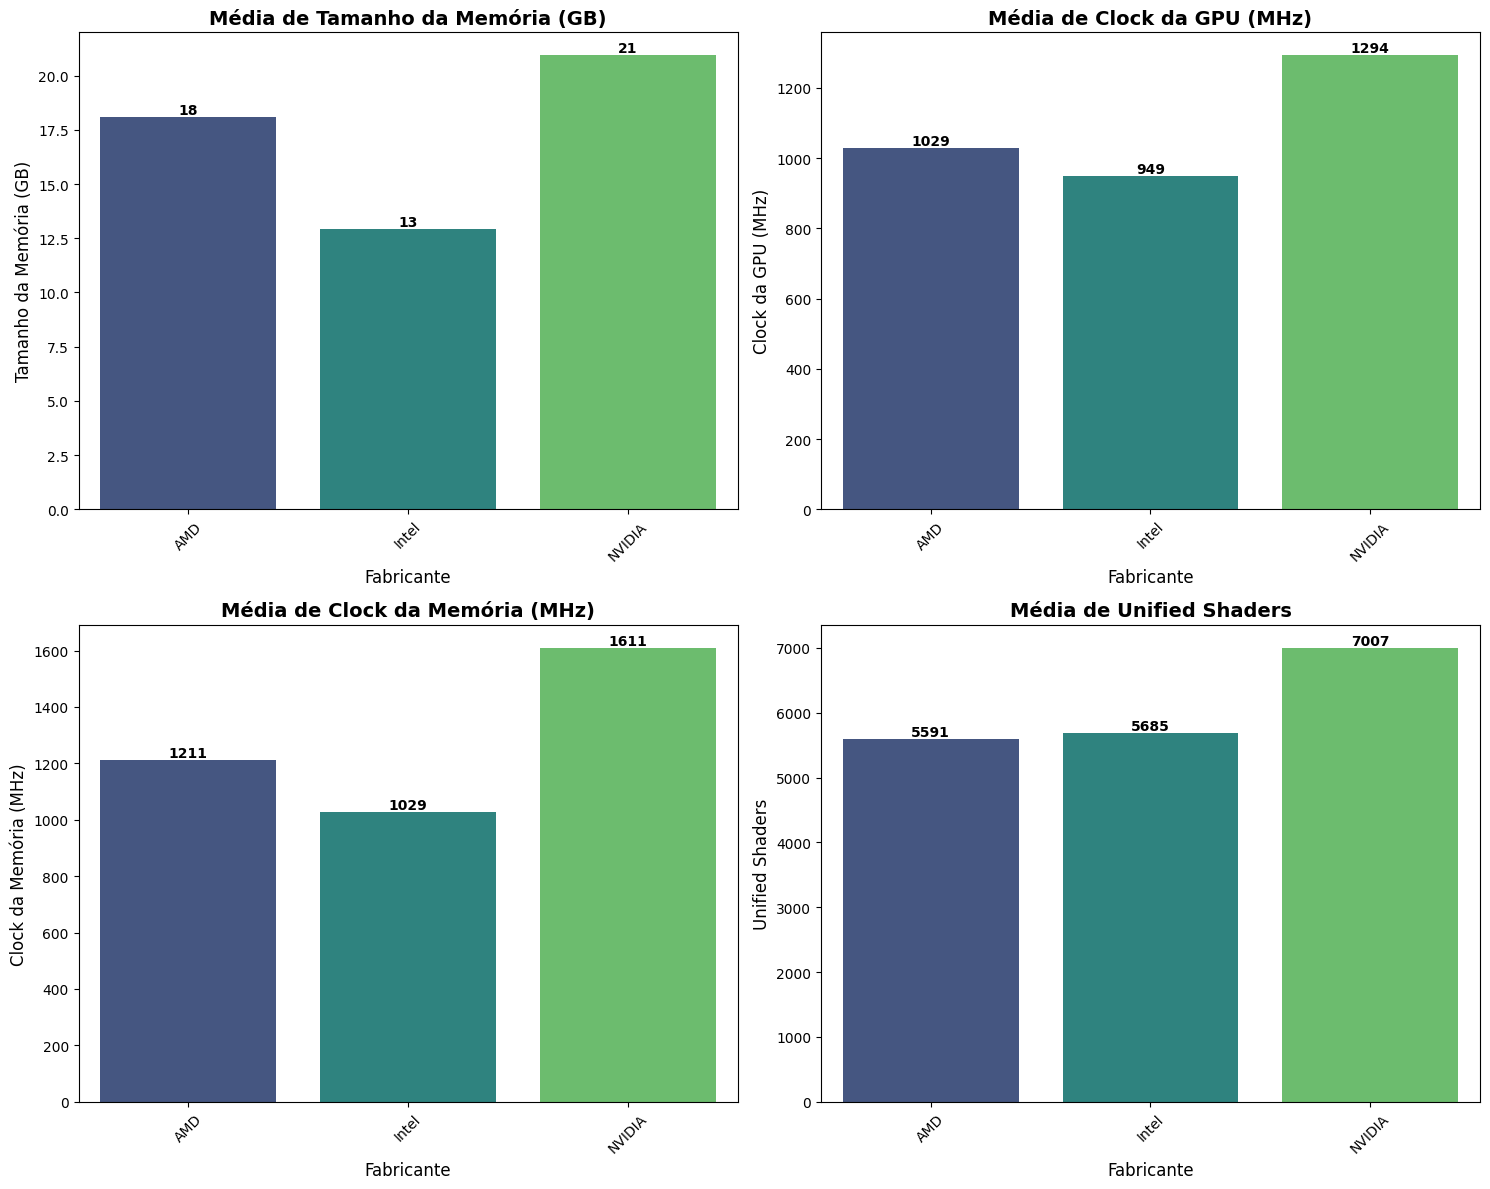


🔍 Análise Visual do Comparativo:
✓ Os gráficos de barras permitem uma visualização clara das diferenças nas médias das especificações entre Intel, NVIDIA e AMD para as GPUs mais recentes.
✓ Podemos observar a estratégia de posicionamento da Intel em relação aos concorrentes tradicionais do mercado.


In [17]:
# 4. Gerar gráficos de barras (subplots) comparando as três marcas em cada métrica

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()

# Títulos e rótulos para os gráficos
plot_titles = {
    'memSize': 'Tamanho da Memória (GB)',
    'gpuClock': 'Clock da GPU (MHz)',
    'memClock': 'Clock da Memória (MHz)',
    'unifiedShader': 'Unified Shaders'
}

for i, metric in enumerate(metrics):
    sns.barplot(x=comparative_means.index, y=comparative_means[metric], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Média de {plot_titles[metric]}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Fabricante', fontsize=12)
    axes[i].set_ylabel(plot_titles[metric], fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

    # Adicionar valores nas barras
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.0f', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🔍 Análise Visual do Comparativo:")
print("✓ Os gráficos de barras permitem uma visualização clara das diferenças nas médias das especificações entre Intel, NVIDIA e AMD para as GPUs mais recentes.")
print("✓ Podemos observar a estratégia de posicionamento da Intel em relação aos concorrentes tradicionais do mercado.")

## 📝 Conclusões e Recomendações

Sumarização das descobertas e sugestões para análises futuras ou tomadas de decisão. 🚀

Com base na análise exploratória realizada, podemos destacar alguns pontos importantes:

*   **Variação de Clocks**: Observamos a gama de velocidades de clock de GPU e memória, que são indicadores cruciais de desempenho.
*   **Distribuição de VRAM**: O histograma de 'memSize' revelou as capacidades de memória mais comuns nas GPUs, indicando tendências de mercado ou segmentos de uso.
*   **Diferenças por Fabricante**: Os gráficos por fabricante mostraram como marcas como NVIDIA e AMD se posicionam em termos de clock e oferta de VRAM, sugerindo estratégias distintas de produto.

### Recomendações:

1.  **Segmentação de Mercado**: Aprofundar a análise para identificar segmentos de mercado específicos (ex: gaming, workstation) e como as especificações das GPUs se adaptam a eles.
2.  **Análise de Preço/Desempenho**: Se dados de preço estiverem disponíveis, seria valioso analisar a relação entre preço, clock e VRAM para determinar o valor de mercado.
3.  **Evolução Tecnológica**: Estudar a evolução das especificações ao longo dos anos ('releaseYear') para identificar o ritmo das inovações e as tendências futuras.